# Handwritten Digit Recognition

# Importing Libraries & Data Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import mnist
from keras import ops
from PIL import Image, ImageStat
#from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
#from sklearn.utils.multiclass import type_of_target
import cv2

## Loading Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(60000, 784).astype("float32") / 255
X_test = X_test.reshape(10000, 784).astype("float32") / 255

In [3]:
X_train = X_train.reshape(-1, 28, 28, 1)

In [4]:
# Reserve 10,000 samples for validation
x_val = X_train[-10000:]
y_val = y_train[-10000:]
X_train = X_train[:-10000]
y_train = y_train[:-10000]

In [5]:
image_train=X_train

### Show Random 30 of Training Images

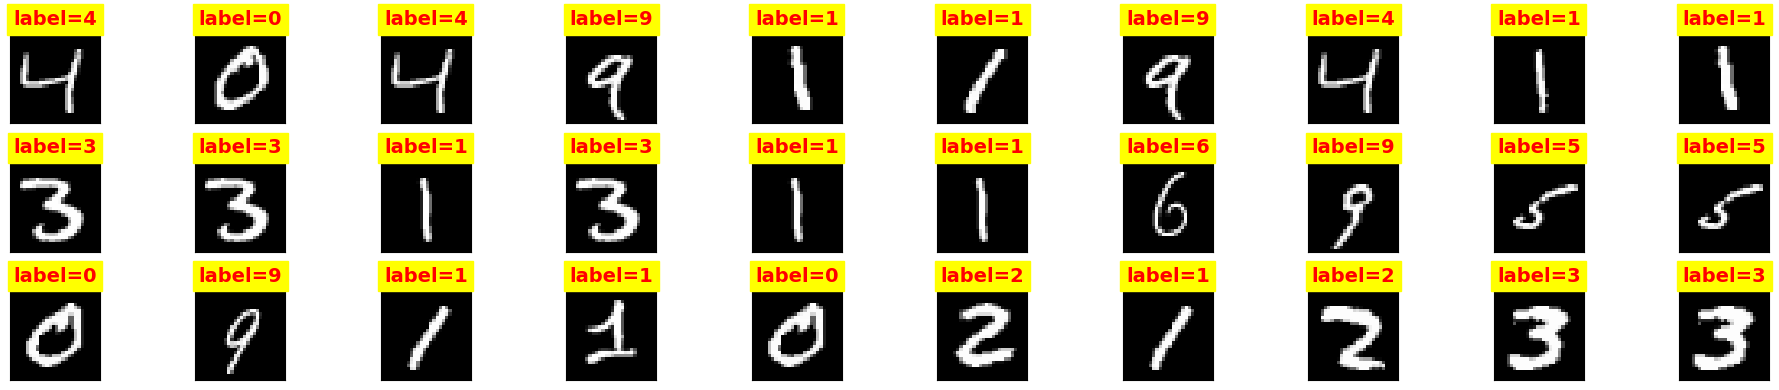

In [6]:
n = 10
c=3
fig,axs=plt.subplots(3,10,figsize=(20,4),layout='tight')
for count in range(c):   
    for i in range(n):
        j=random.randint(0,i+1)
        axs[count][i].imshow(X_train[j+count*10+1].reshape(28, 28),cmap='gray')
        axs[count][i].title.set_fontsize(14)
        axs[count][i].title.set_fontweight('bold')
        axs[count][i].title.set_text('label='+str(y_train[j+count*10+1]))
        axs[count][i].title.set_color('red')
        axs[count][i].title.set_backgroundcolor('yellow')
        axs[count][i].get_xaxis().set_visible(False)
        axs[count][i].get_yaxis().set_visible(False)
        

In [7]:
model=tf.keras.models.load_model("Model07-29-2026-23-50.keras")

## Try to Recognize Given Data

In [8]:
# Load the digit image to be recognized
import tkinter
from tkinter import filedialog
file=tkinter.filedialog.askopenfilenames()

In [9]:
# Copy the original image to display at the end
image=cv2.imread(file[0])
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
copy=image.copy()
image=cv2.resize(image,(28,28))

In [10]:
def is_image_inverted(image_path):
    img=Image.fromarray(image_path).convert('L')
    stat = ImageStat.Stat(img)
    mean_brightness = stat.mean[0]
    return mean_brightness > 127

In [11]:
#Check if the image is inverted. The training dataset was with white digits on black background. If the input image is reversed, will be inverted. 
image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
image=cv2.resize(image,(28,28))
if is_image_inverted(image):
   image=np.invert(image)

In [12]:
# Normalize the image and send to model for prediction
image=image/255.
img_array = keras.utils.img_to_array(image)
img_array = img_array.reshape(-1, 28, 28, 1)
pred=model.predict(img_array)
y_pred=np.argmax(pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


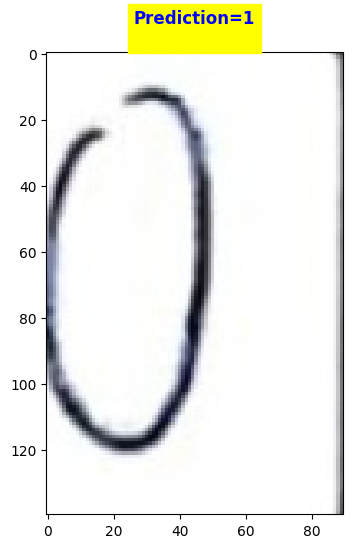

In [13]:
# Show the original image and thhe predicted label
fig, ax = plt.subplots(figsize=(6,6))
ax.set_title('Prediction={}\n'.format(y_pred[0]))
ax.title.set_backgroundcolor('yellow')
ax.title.set_color('blue')
ax.title.set_fontweight('bold')
plt.imshow(copy)
